# Neural Networks From Scratch

In [13]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt 

In [2]:

class Layer:
    def forward(self, x, training=True):
        raise NotImplementedError
    
    def backward(self, grad):
        raise NotImplementedError

    def update(self, lr):
        pass


In [16]:
"""
Dense Layer class actually takes the layer and does the forward and backward pass on it and updates the model weights
"""

class Dense(Layer):
    def __init__(self, input_dim, output_dim):
        limit = np.sqrt(6 / (input_dim + output_dim)) # Xavier initialization
        self.W = np.random.uniform(-limit, limit, (input_dim, output_dim))
        self.b = np.zeros((1, output_dim))

        self.x = None 
        self.dW = None 
        self.db = None 

    def forward(self, x, training=True):
        self.x = x
        return x @ self.W + self.b

    def backward(self, grad):
        batch_size = self.x.shape[0]

        self.dW = self.x.T @ grad / batch_size
        self.db = np.sum(grad, axis=0, keepdims=True) / batch_size

        dx = grad @ self.W.T
        return dx

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db


In [17]:

class ReLU(Layer):
    def __init__(self):
        self.x = None
    
    def forward(self, x, training=True):
        self.x = x
        return np.maximum(0, x)

    def backward(self, grad):
        return grad * (self.x > 0)


class Sigmoid(Layer):
    def __init__(self):
        self.out = None
    
    def forward(self, x, training=True):
        self.out = 1 / (1 + np.exp(-x))
        return self.out 

    def backward(self, grad):
        return grad * self.out * (1 - self.out)


class Tanh(Layer):
    def __init__(self):
        self.out = None 
        
    def forward(self, x, training=True):
        self.out = np.tanh(x)
        return self.out 

    def backward(self, grad):
        return grad * (1 - self.out ** 2)



In [18]:
"""Dropout randomly turns off some neurons during training 
This ensures that ther network learns various different patterns """

class Dropout(Layer):
    def __init__(self, drop_prob):
        # probablity of dropping a neuron 
        if not 0 <= drop_prob < 1:
            raise ValueError("drop_prob must be in range [0, 1)")

        self.drop_prob = drop_prob
        self.keep_prob = 1 - drop_prob 
        self.mask = None 

    def forward(self, x, training=True):
        if not training: return x 

        self.mask = (np.random.rand(*x.shape) < self.keep_prob)

        # inverted dropout scaling 
        return x * self.mask / self.keep_prob 

    def backward(self, grad):
        return grad * self.mask / self.keep_prob 


In [19]:
"""
Layer Normalization Normalizes each example independently across its features
for a batch like this: x.shape = (batch_size, features)

Layer Norm computes mean and variance across the feature dimensions 
mean.shape = (batch_size, 1)
var.shape = (batch_size, 1)
"""

# this class is written by chatgpt
class LayerNorm(Layer):
    def __init__(self, feature_dim, eps=1e-5):
        self.gamma = np.ones((1, feature_dim))
        self.beta = np.zeros((1, feature_dim))
        self.eps = eps

        self.x = None
        self.mean = None
        self.var = None
        self.x_hat = None

        self.dgamma = None
        self.dbeta = None

    def forward(self, x, training=True):
        self.x = x

        self.mean = np.mean(x, axis=1, keepdims=True)
        self.var = np.var(x, axis=1, keepdims=True)

        self.x_hat = (x - self.mean) / np.sqrt(self.var + self.eps)

        return self.gamma * self.x_hat + self.beta

    def backward(self, grad):
        # grad shape: (batch_size, feature_dim)

        batch_size, feature_dim = grad.shape

        self.dgamma = np.sum(grad * self.x_hat, axis=0, keepdims=True)
        self.dbeta = np.sum(grad, axis=0, keepdims=True)

        dx_hat = grad * self.gamma

        std_inv = 1.0 / np.sqrt(self.var + self.eps)

        x_mu = self.x - self.mean

        dvar = np.sum(
            dx_hat * x_mu * -0.5 * std_inv**3,
            axis=1,
            keepdims=True
        )

        dmean = (
            np.sum(dx_hat * -std_inv, axis=1, keepdims=True)
            +dvar * np.mean(-2.0 * x_mu, axis=1, keepdims=True)
        )

        dx = (
            dx_hat * std_inv
            + dvar * 2.0 * x_mu / feature_dim
            + dmean / feature_dim
        )

        return dx

    def update(self, lr):
        self.gamma -= lr * self.dgamma
        self.beta -= lr * self.dbeta


In [20]:
# What does each class do?
#
# Layer is an interface for other classes to use 
# Dense is a collection of Layers which can call forward and backward 
# ReLU and Sigmoid are classes for returning activations
# Dropout regularizes the model output at each step
# Model is where all the functions get called on the network 


class Model:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x, training=True):
        for layer in self.layers:
            x = layer.forward(x, training=training)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def predict(self, x):
        return self.forward(x, training=False)


In [21]:

# Loss functions 
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def mse_grad(y_pred, y_true):
    return 2 * (y_pred - y_true)


# Mini-Batch-Training: training on chuncks of the dataset instead of training on whole 
def get_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]

    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, n, batch_size):
        end = start + batch_size 
        batch_indices = indices[start:end]

        yield X[batch_indices], y[batch_indices]


In [22]:

# Training FUnction 
def train(model, X, y, epochs=1000, batch_size=32, lr=0.01):
    for epoch in range(epochs):
        epoch_loss = 0 # trainig loss for that epoch 
        num_batches = 0

        for X_batch, y_batch in get_batches(X, y, batch_size):

            # running forward pass on input batch: X_batch
            y_pred = model.forward(X_batch, training=True)

            loss = mse_loss(y_pred, y_batch)
            grad = mse_grad(y_pred, y_batch)

            # running backward pass on gradient
            model.backward(grad)

            # updating model weights
            model.update(lr)

            epoch_loss += loss
            num_batches += 1

        epoch_loss /= num_batches

        if epoch % 100 == 0:
            print(f"epoch={epoch}, loss={epoch_loss:.6f}")


epoch=0, loss=0.444058
epoch=100, loss=0.078985
epoch=200, loss=0.052961
epoch=300, loss=0.041710
epoch=400, loss=0.018383
epoch=500, loss=0.002922
epoch=600, loss=0.001100
epoch=700, loss=0.000736
epoch=800, loss=0.000589
epoch=900, loss=0.000440
epoch=1000, loss=0.000464
epoch=1100, loss=0.000311
epoch=1200, loss=0.000400
epoch=1300, loss=0.000335
epoch=1400, loss=0.000316
epoch=1500, loss=0.000383
epoch=1600, loss=0.000355
epoch=1700, loss=0.000323
epoch=1800, loss=0.000292
epoch=1900, loss=0.000216
epoch=2000, loss=0.000260
epoch=2100, loss=0.000224
epoch=2200, loss=0.000217
epoch=2300, loss=0.000162
epoch=2400, loss=0.000190
epoch=2500, loss=0.000171
epoch=2600, loss=0.000141
epoch=2700, loss=0.000235
epoch=2800, loss=0.000197
epoch=2900, loss=0.000179
epoch=3000, loss=0.000139
epoch=3100, loss=0.000130
epoch=3200, loss=0.000110
epoch=3300, loss=0.000160
epoch=3400, loss=0.000169
epoch=3500, loss=0.000106
epoch=3600, loss=0.000249
epoch=3700, loss=0.000160
epoch=3800, loss=0.00010

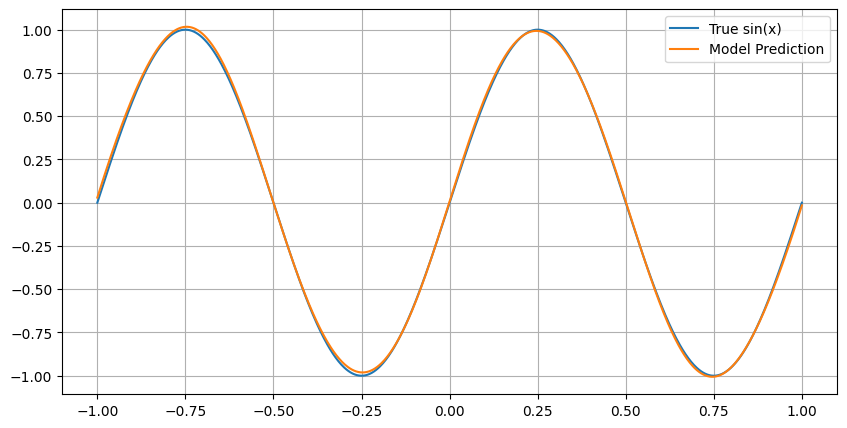

In [23]:


np.random.seed(42)

# SINE FUNCTION 
raw_X = np.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)
X = raw_X / (2 * np.pi)
y = np.sin(raw_X)


# Building Model 

model = Model([
    Dense(1, 64),
    # LayerNorm(64),
    # ReLU(),
    # Dropout(0.1),
    Tanh(),

    Dense(64, 64),
    # LayerNorm(64),
    # ReLU(),
    # Dropout(0.2),
    Tanh(),

    Dense(64, 64),
    Tanh(),

    Dense(64, 64),
    Tanh(),

    Dense(64, 1),
    # Sigmoid()
])


train(model, X, y, epochs=5000, batch_size=32, lr=0.01)

y_pred = model.predict(X)


plt.figure(figsize=(10,5))
plt.plot(X, y, label="True sin(x)")
plt.plot(X, y_pred, label="Model Prediction")
plt.legend()
plt.grid(True)
plt.show()
